# 4. Health metrics frequency of measurements
(Except for sleep stage)

In [1]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/add_treatment_to_df.R")
source("../util/samples_processing.R")
source("../util/outliers_processing.R")
source("../util/plot_helpers.R")

ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘HLMdiag’


The following object is masked from ‘package:stats’:

    covratio



Attaching package: ‘data.table’


In [2]:
ALL_SAMPLES_RAW_DATA <- process_data_file(
    file_path = "../raw-data/samples.csv",
    ALL_PARTICIPANTS_METADATA = ALL_PARTICIPANTS_METADATA
)
ALL_SAMPLES_RAW_DATA <- calculate_interval_between_consecutive_samples(
    data = ALL_SAMPLES_RAW_DATA
)

## 4.1. Intervals between measurements (naive approach)
Summarize time elapsed between 2 consecutive samples, even if there might be a long gap due to non-wear time

In [3]:
mean_intervals_by_participant <- ALL_SAMPLES_RAW_DATA |>
  summarise(
    mean_interval_start_start_sec = mean(interval_start_start_sec, na.rm = TRUE),
    mean_interval_end_start_sec = mean(interval_end_start_sec, na.rm = TRUE),
    median_interval_start_start_sec = median(interval_start_start_sec, na.rm = TRUE),
    trimmed_mean_interval_start_start_sec = mean(interval_start_start_sec, trim = 0.05, na.rm = TRUE),
    count_intervals = sum(!is.na(interval_start_start_sec)),
    .groups = "drop"
  )

head(mean_intervals_by_participant)

mean_interval_start_start_sec,mean_interval_end_start_sec,median_interval_start_start_sec,trimmed_mean_interval_start_start_sec,count_intervals
<dbl>,<dbl>,<dbl>,<dbl>,<int>
1397.581,1241.127,137,232.3829,588844


In [4]:
mean_duration_by_period <- ALL_SAMPLES_RAW_DATA |>
  filter(!is.na(interval_start_start_sec)) |>
  group_by(sample_type_id) |>
  summarise(
    mean_interval_start_start_sec = mean(interval_start_start_sec),
    mean_interval_end_start_sec = mean(interval_end_start_sec, na.rm = TRUE),
    total_intervals = n(),
    .groups = "drop"
  )

mean_duration_by_period

sample_type_id,mean_interval_start_start_sec,mean_interval_end_start_sec,total_intervals
<chr>,<dbl>,<dbl>,<int>
heart-rate,246.3735,246.3735,485883
heartbeat-series,17839.5806,17781.3000,6681
hrv,17839.5806,17781.3000,6681
oxygen-saturation,7547.3157,7547.3157,15373
respiratory-rate,2628.2313,2628.2313,44453
resting-heart-rate,118187.3737,52147.0764,982
sleep,4027.5943,3107.2828,28791


## 4.2. Intervals between measurements (adjust for non-wear gaps)

### 4.2.1. Continuous wear-time segmentation
A continous wear segment is defined as periods where two consecutive `heart-rate` measurements are less than `NON_WEAR_GAP_IN_SECONDS`

Otherwise, we assume that those 2 measurements are sandwiched by a non-wear gap

In [5]:
NON_WEAR_GAP_IN_SECONDS = 3600 # 1 hour

In [6]:
hr_intervals <- ALL_SAMPLES_RAW_DATA |>
  filter(sample_type_id == "heart-rate") |>
  arrange(pseudonym, start_date) |>
  group_by(pseudonym) |>
  mutate(non_wear_gap = interval_start_start_sec > NON_WEAR_GAP_IN_SECONDS,
         wear_segment = cumsum(replace_na(non_wear_gap, FALSE)))

In [7]:
hr_dt <- ALL_SAMPLES_RAW_DATA |>
  filter(sample_type_id == "heart-rate") |>
  arrange(pseudonym, start_date) |>
  group_by(pseudonym) |>
  mutate(
    interval = as.numeric(difftime(start_date, lag(start_date), units = "secs")),
    non_wear = if_else(interval > NON_WEAR_GAP_IN_SECONDS, 1, 0),
    wear_segment = cumsum(replace_na(non_wear, 0))
  ) |>
  select(pseudonym, start_date, wear_segment) |>
  ungroup() |>
  as.data.table()

setkey(hr_dt, pseudonym, start_date)


In [8]:
samples_dt <- as.data.table(ALL_SAMPLES_RAW_DATA)
setkey(samples_dt, pseudonym, start_date)

samples_dt_with_segment <- hr_dt[samples_dt, roll = TRUE]

In [9]:
samples_dt_with_segment_and_interval <- samples_dt_with_segment |>
  group_by(pseudonym, sample_type_id, wear_segment) |>
  arrange(pseudonym, sample_type_id, start_date) |>
  mutate(minutes_after_previous_measurement_same_segment = as.numeric(difftime(start_date, lag(start_date), units = "mins"))) |>
  filter(!is.na(minutes_after_previous_measurement_same_segment)) |>  # Remove first row of each group (no interval)
  filter(minutes_after_previous_measurement_same_segment != 0) |>
  select(sample_type_id, pseudonym, wear_segment, start_date, end_date, minutes_after_previous_measurement_same_segment)

samples_dt_with_segment_and_interval_outlier_removed <- remove_outliers_iqr_method(
  data = samples_dt_with_segment_and_interval,
  value_column = "minutes_after_previous_measurement_same_segment",
  group_by_column = c("sample_type_id")
)

### 4.2.2. Summarize and format for Latex

In [10]:
summary_interval_per_metric <- samples_dt_with_segment_and_interval_outlier_removed |>
  filter(sample_type_id %in% names(HEALTH_METRIC_NAMES)) |>
  group_by(sample_type_id) |>
  summarise(
    mean = mean(minutes_after_previous_measurement_same_segment, na.rm = TRUE),
    sd = sd(minutes_after_previous_measurement_same_segment, na.rm = TRUE),
    median = median(minutes_after_previous_measurement_same_segment, na.rm = TRUE),
    q25 = quantile(minutes_after_previous_measurement_same_segment, probs = 0.25, na.rm = TRUE),
    q75 = quantile(minutes_after_previous_measurement_same_segment, probs = 0.75, na.rm = TRUE),
    .groups = "drop"
  ) |>
  mutate(
    metric_name = HEALTH_METRIC_NAMES[sample_type_id],
    mean_pm_sd = sprintf("%.1f $\\pm$ %.1f", mean, sd),
    median_q25_q75 = sprintf("%.1f [%.1f, %.1f]", median, q25, q75)
  ) |>
  select(
    metric_name,
    mean_pm_sd,
    median_q25_q75
  )

summary_interval_per_metric

latex_tbl <- kable(
  summary_interval_per_metric,
  format = "latex",
  booktabs = TRUE,
  escape = FALSE,
  align = "lcc",
  col.names = c("HealthMetric", MEAN_PM_SD, MEDIAN_Q1_Q3),
  label = "health_metrics_interval_summary"
) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric_name,mean_pm_sd,median_q25_q75
<chr>,<chr>,<chr>
HR,2.3 $\pm$ 2.7,"0.5 [0.1, 4.4]"
HRV,174.0 $\pm$ 73.1,"170.8 [120.0, 240.0]"
SpO2,43.2 $\pm$ 20.4,"30.8 [30.0, 55.2]"
Sleep RR,10.0 $\pm$ 4.3,"10.0 [7.0, 13.1]"
RHR,1435.7 $\pm$ 14.1,"1439.7 [1436.2, 1441.7]"


\begin{table}[!h]
\centering
\begin{tabular}{lcc}
\toprule
HealthMetric & Mean $\pm$ SD & Median [Q1, Q3]\\
\midrule
HR & 2.3 $\pm$ 2.7 & 0.5 [0.1, 4.4]\\
HRV & 174.0 $\pm$ 73.1 & 170.8 [120.0, 240.0]\\
SpO2 & 43.2 $\pm$ 20.4 & 30.8 [30.0, 55.2]\\
Sleep RR & 10.0 $\pm$ 4.3 & 10.0 [7.0, 13.1]\\
RHR & 1435.7 $\pm$ 14.1 & 1439.7 [1436.2, 1441.7]\\
\bottomrule
\end{tabular}
\end{table}

### 4.2.3. Histograms

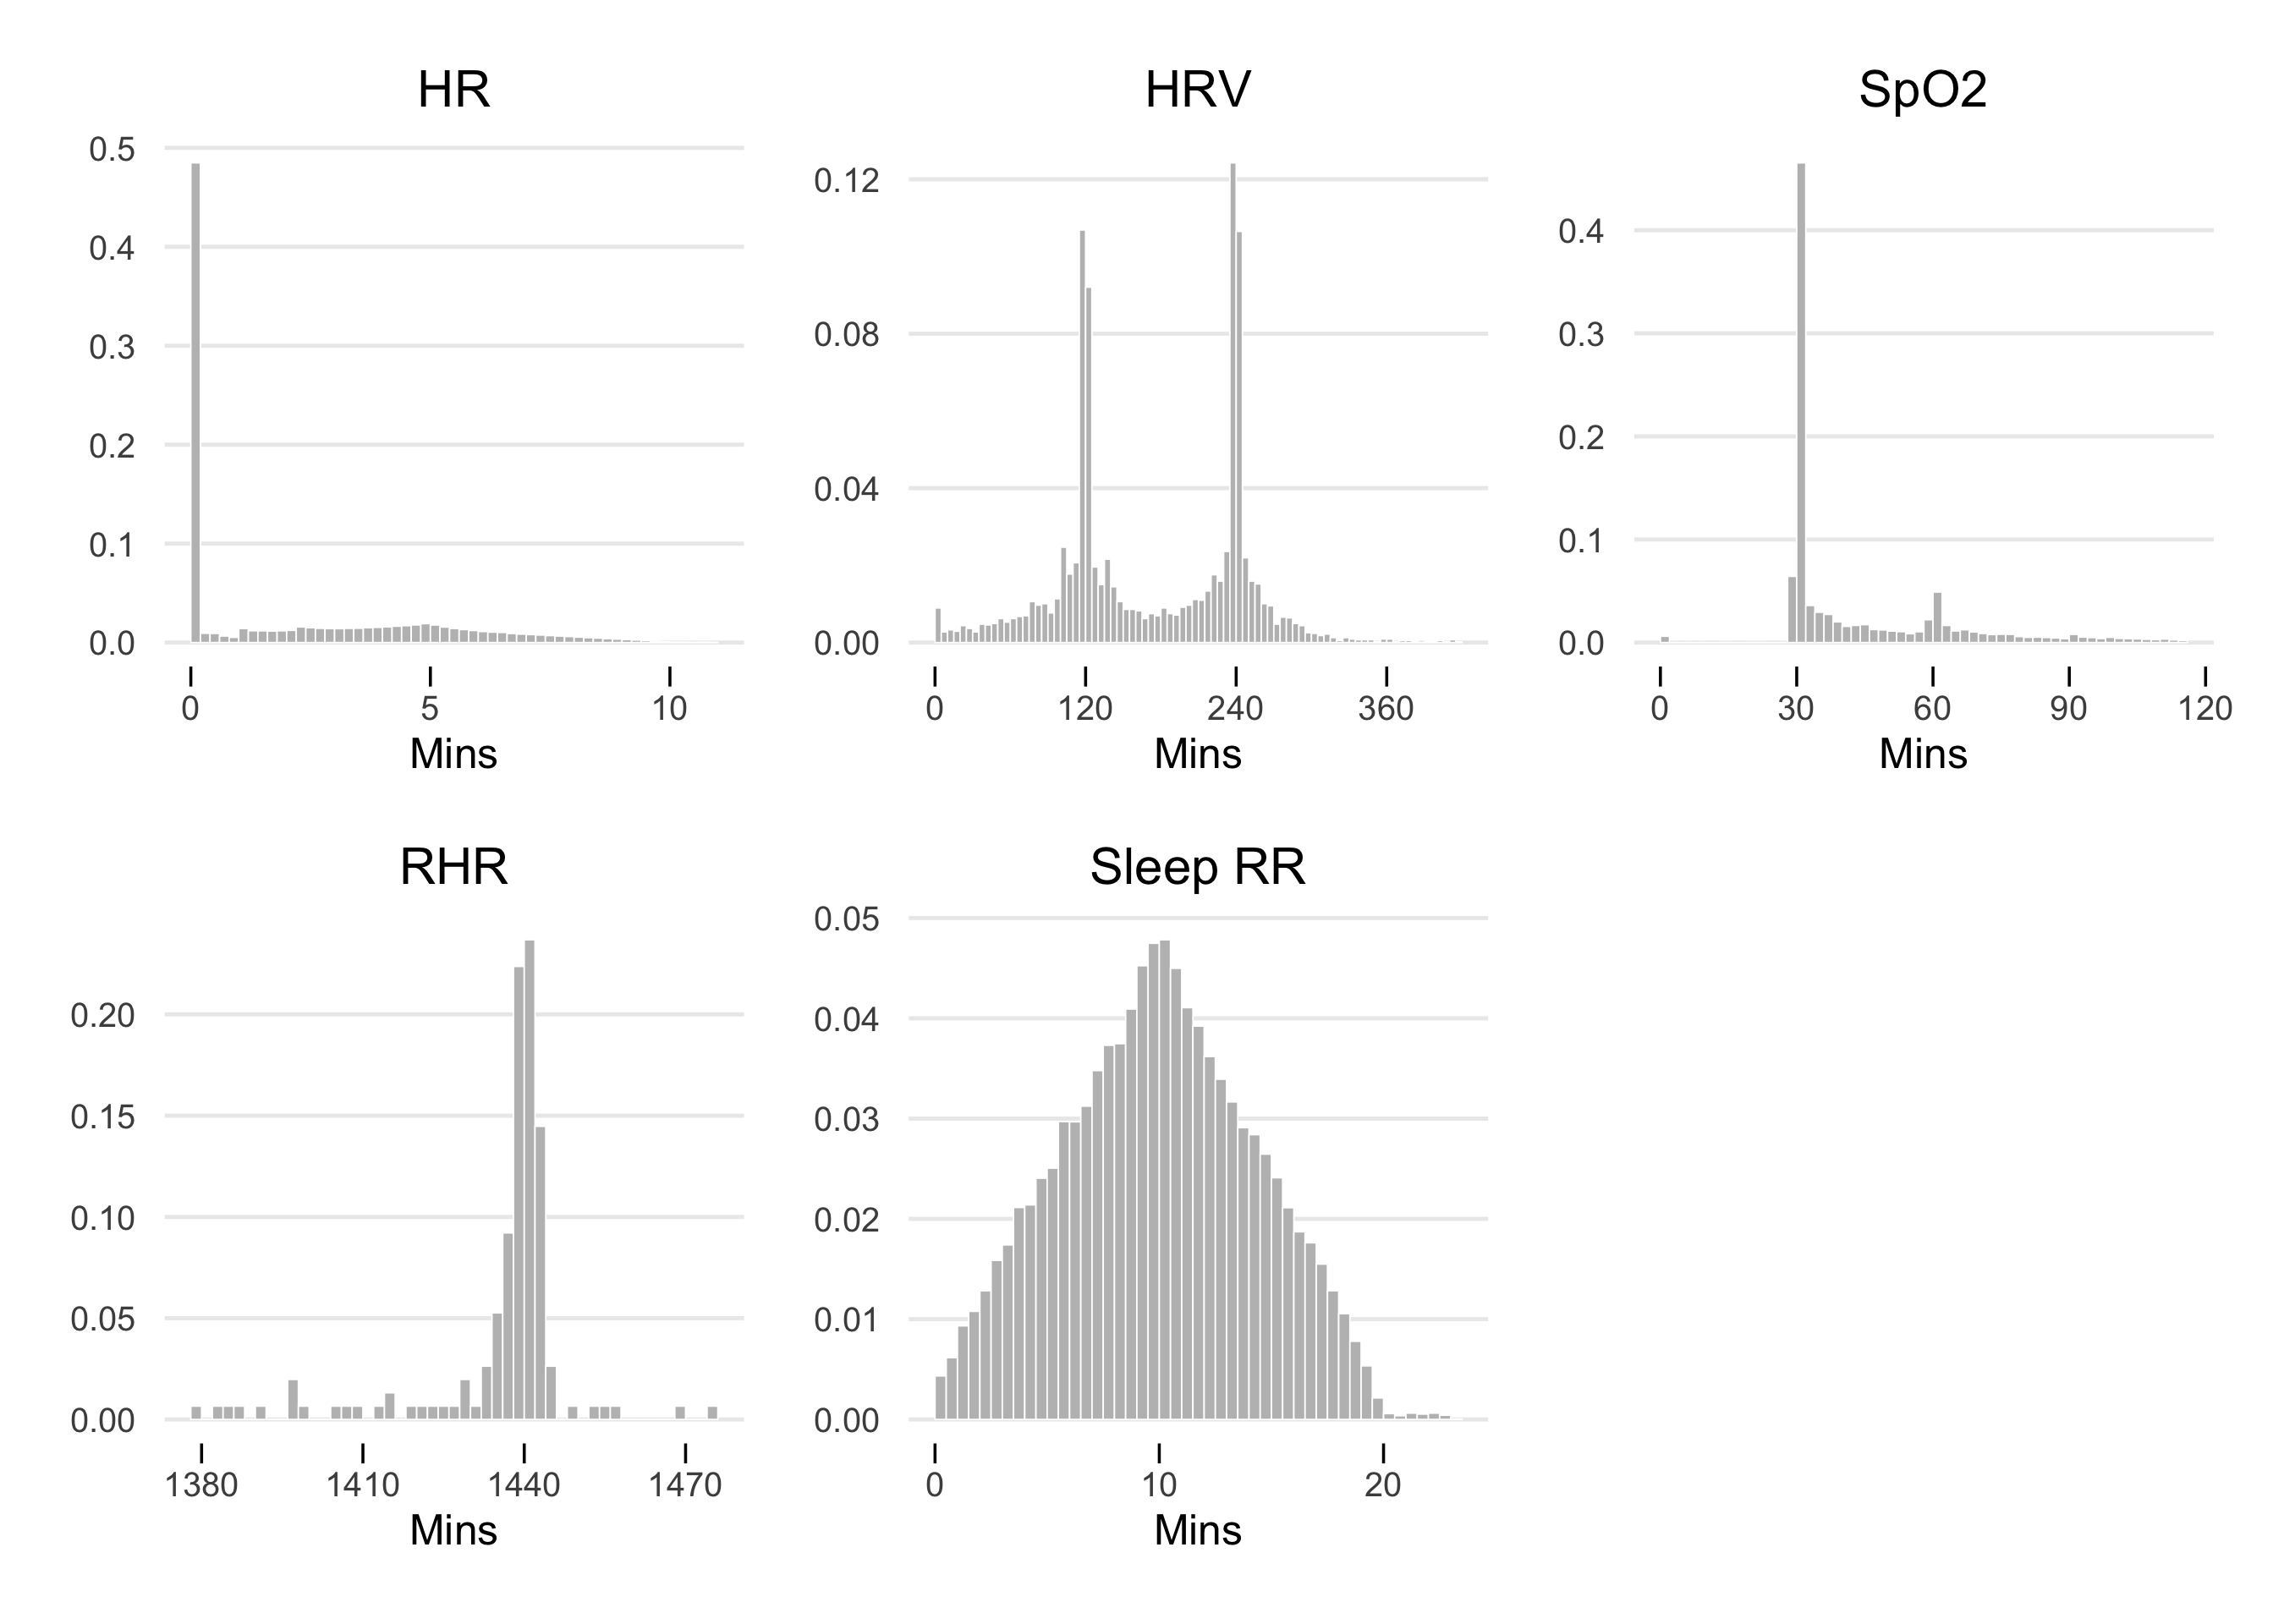

In [11]:
dimension <- plot_dimension(is_vertical = FALSE)

options(repr.plot.width = dimension$width * 1.5, repr.plot.height = dimension$height * 2)

plot_metric_hist <- function(data, metric_id, breaks, bins = 60) {
    metric_label <- HEALTH_METRIC_NAMES[metric_id]

    hist_data <- data |>
        filter(sample_type_id == metric_id) |>
        pull(minutes_after_previous_measurement_same_segment) |>
        hist(breaks = bins, plot = FALSE)

    df <- tibble(
        mids = hist_data$mids,
        density = hist_data$counts / sum(hist_data$counts)
    )

    ggplot(df, aes(x = mids, y = density)) +
        geom_col(fill = "gray", color = "white", width = diff(hist_data$breaks)[1]) +
        scale_x_continuous(breaks = breaks) +
        labs(
            x = "Mins",
            y = NULL,
            title = metric_label
        ) +
        THEME_MINIMAL
}

# Define breaks per metric
metric_plots <- list(
    plot_metric_hist(samples_dt_with_segment_and_interval_outlier_removed, HR, seq(0, 10, by = 5)),
    plot_metric_hist(samples_dt_with_segment_and_interval_outlier_removed, HRV, seq(0, 480, by = 120)),
    plot_metric_hist(samples_dt_with_segment_and_interval_outlier_removed, SPO2, seq(0, 120, by = 30)),
    plot_metric_hist(samples_dt_with_segment_and_interval_outlier_removed, RHR, seq(1380, 1500, by = 30)),
    plot_metric_hist(samples_dt_with_segment_and_interval_outlier_removed, RR, seq(0, 30, by = 10))
)

# Combine them with patchwork
p <- wrap_plots(metric_plots, ncol = 3) + 
  plot_layout(guides = "collect") & 
  theme(
    plot.margin = margin(25, 25, 25, 25),
    plot.title = element_text(hjust = 0.5)
  )
p

# Save it
ggsave("../visualization/sampling_rate_histograms.pdf", p, width = dimension$width * 1.5, height = dimension$height * 2, dpi = 300)
